1、使用pyTorch

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

In [2]:
# 生成示例数据
np.random.seed(42)
time_steps = np.arange(0, 1000, 0.1)
data = np.sin(time_steps * 0.1) + np.random.normal(0, 0.1, len(time_steps))

# 数据预处理
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data.reshape(-1, 1))

# 创建序列数据
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

SEQ_LENGTH = 50
X, y = create_sequences(data_scaled, SEQ_LENGTH)

# 转换为PyTorch张量
X_tensor = torch.FloatTensor(X).view(-1, SEQ_LENGTH, 1)
y_tensor = torch.FloatTensor(y)

In [3]:
# 划分数据集
X_train, X_test, y_train, y_test = train_test_split(
    X_tensor.numpy(), y_tensor.numpy(), test_size=0.2, shuffle=False
)
X_train = torch.FloatTensor(X_train).view(-1, SEQ_LENGTH, 1)
X_test = torch.FloatTensor(X_test).view(-1, SEQ_LENGTH, 1)
y_train = torch.FloatTensor(y_train)
y_test = torch.FloatTensor(y_test)

# 定义LSTM模型
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, num_layers=2, output_size=1):
        super(LSTMModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.2
        )
        
        self.fc = nn.Linear(hidden_size, output_size)
        
    def forward(self, x):
        # 初始化隐藏状态
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        
        # LSTM前向传播
        out, _ = self.lstm(x, (h0, c0))
        
        # 取最后一个时间步
        out = out[:, -1, :]
        
        # 全连接层
        out = self.fc(out)
        return out

In [4]:

# 初始化模型
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = LSTMModel().to(device)

# 定义损失函数和优化器
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 训练模型
num_epochs = 100
batch_size = 32

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0
    
    # 批量训练
    for i in range(0, len(X_train), batch_size):
        batch_x = X_train[i:i+batch_size].to(device)
        batch_y = y_train[i:i+batch_size].to(device)
        
        # 前向传播
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        
        # 反向传播
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
    
    if (epoch+1) % 20 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss/len(X_train):.6f}')

Epoch [20/100], Loss: 0.000162
Epoch [40/100], Loss: 0.000067
Epoch [60/100], Loss: 0.000088
Epoch [80/100], Loss: 0.000076
Epoch [100/100], Loss: 0.000061


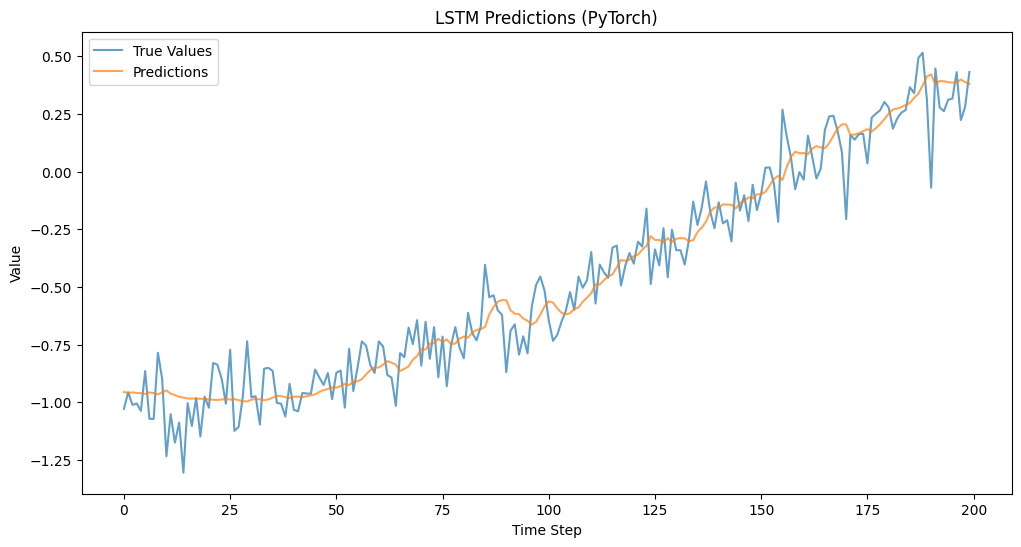

In [5]:
# 预测
model.eval()
with torch.no_grad():
    train_predict = model(X_train.to(device))
    test_predict = model(X_test.to(device))

# 反标准化
train_predict = scaler.inverse_transform(train_predict.cpu().numpy())
test_predict = scaler.inverse_transform(test_predict.cpu().numpy())
y_train_orig = scaler.inverse_transform(y_train.numpy())
y_test_orig = scaler.inverse_transform(y_test.numpy())

# 可视化
plt.figure(figsize=(12, 6))
plt.plot(y_test_orig[:200], label='True Values', alpha=0.7)
plt.plot(test_predict[:200], label='Predictions', alpha=0.7)
plt.title('LSTM Predictions (PyTorch)')
plt.xlabel('Time Step')
plt.ylabel('Value')
plt.legend()
plt.show()

2、使用KAN数据进行LSTM

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from kan.utils import create_dataset

# 检查是否有GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [7]:
# 1. 创建数据集
f = lambda x: torch.exp(torch.sin(torch.pi*x[:,[0]]) + x[:,[1]]**2)

# 创建数据集
dataset = create_dataset(f, n_var=2, device=device)
print(f"训练输入形状: {dataset['train_input'].shape}")
print(f"训练标签形状: {dataset['train_label'].shape}")

# 2. 数据预处理
# 将数据移到CPU进行预处理（如果需要）
train_input = dataset['train_input'].cpu().numpy()
train_label = dataset['train_label'].cpu().numpy()
test_input = dataset['test_input'].cpu().numpy()
test_label = dataset['test_label'].cpu().numpy()

# 标准化
input_scaler = StandardScaler()
label_scaler = StandardScaler()

train_input_scaled = input_scaler.fit_transform(train_input)
train_label_scaled = label_scaler.fit_transform(train_label)
test_input_scaled = input_scaler.transform(test_input)
test_label_scaled = label_scaler.transform(test_label)

# 3. 为LSTM重塑数据格式
# LSTM期望的形状: (batch_size, sequence_length, features)
# 我们将2个特征视为2个时间步的特征序列
def reshape_for_lstm(X, sequence_length=1):
    """将特征重塑为序列格式"""
    # 如果sequence_length=1，每个样本只有一个时间步
    return X.reshape(-1, sequence_length, X.shape[1])

SEQ_LENGTH = 1  # 每个样本的"时间步"数
n_features = 2  # 每个时间步的特征数

train_input_reshaped = reshape_for_lstm(train_input_scaled, SEQ_LENGTH)
test_input_reshaped = reshape_for_lstm(test_input_scaled, SEQ_LENGTH)

print(f"重塑后的训练输入形状: {train_input_reshaped.shape}")
print(f"重塑后的测试输入形状: {test_input_reshaped.shape}")

# 转换为PyTorch张量
X_train = torch.FloatTensor(train_input_reshaped).to(device)
y_train = torch.FloatTensor(train_label_scaled).to(device)
X_test = torch.FloatTensor(test_input_reshaped).to(device)
y_test = torch.FloatTensor(test_label_scaled).to(device)

训练输入形状: torch.Size([1000, 2])
训练标签形状: torch.Size([1000, 1])
重塑后的训练输入形状: (1000, 1, 2)
重塑后的测试输入形状: (1000, 1, 2)


In [8]:
# 4. 定义LSTM模型
class LSTMPredictor(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers=1, output_size=1):
        super(LSTMPredictor, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        # LSTM层
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.2 if num_layers > 1 else 0
        )
        
        # 全连接层
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, output_size)
        )
        
    def forward(self, x):
        # 初始化隐藏状态
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        
        # LSTM前向传播
        lstm_out, _ = self.lstm(x, (h0, c0))
        
        # 取最后一个时间步的输出
        out = lstm_out[:, -1, :]
        
        # 全连接层
        out = self.fc(out)
        return out

# 初始化模型
model = LSTMPredictor(
    input_size=n_features,
    hidden_size=64,
    num_layers=2,
    output_size=1
).to(device)

# 5. 定义损失函数和优化器
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5)

In [9]:
# 6. 训练模型
def train_model(model, X_train, y_train, X_test, y_test, epochs=200, batch_size=32):
    train_losses = []
    val_losses = []
    
    # 创建数据加载器
    from torch.utils.data import DataLoader, TensorDataset
    train_dataset = TensorDataset(X_train, y_train)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    
    for epoch in range(epochs):
        model.train()
        train_loss = 0
        
        for batch_x, batch_y in train_loader:
            optimizer.zero_grad()
            
            # 前向传播
            predictions = model(batch_x)
            loss = criterion(predictions, batch_y)
            
            # 反向传播
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            
            train_loss += loss.item()
        
        # 验证
        model.eval()
        with torch.no_grad():
            val_predictions = model(X_test)
            val_loss = criterion(val_predictions, y_test)
        
        avg_train_loss = train_loss / len(train_loader)
        train_losses.append(avg_train_loss)
        val_losses.append(val_loss.item())
        
        # 学习率调度
        scheduler.step(val_loss)
        
        if (epoch + 1) % 20 == 0:
            print(f'Epoch [{epoch+1}/{epochs}], '
                  f'Train Loss: {avg_train_loss:.6f}, '
                  f'Val Loss: {val_loss.item():.6f}')
    
    return train_losses, val_losses

# 训练
print("\n开始训练LSTM模型...")
train_losses, val_losses = train_model(
    model, X_train, y_train, X_test, y_test, 
    epochs=200, batch_size=64
)


开始训练LSTM模型...
Epoch [20/200], Train Loss: 0.303549, Val Loss: 0.269228
Epoch [40/200], Train Loss: 0.104676, Val Loss: 0.046346
Epoch [60/200], Train Loss: 0.080628, Val Loss: 0.015718
Epoch [80/200], Train Loss: 0.061458, Val Loss: 0.014621
Epoch [100/200], Train Loss: 0.060920, Val Loss: 0.009865
Epoch [120/200], Train Loss: 0.052014, Val Loss: 0.007733
Epoch [140/200], Train Loss: 0.047128, Val Loss: 0.007667
Epoch [160/200], Train Loss: 0.050390, Val Loss: 0.007917
Epoch [180/200], Train Loss: 0.052692, Val Loss: 0.006826
Epoch [200/200], Train Loss: 0.045362, Val Loss: 0.006220


In [10]:
# 7. 评估模型
model.eval()
with torch.no_grad():
    # 训练集预测
    train_pred_scaled = model(X_train).cpu().numpy()
    test_pred_scaled = model(X_test).cpu().numpy()
    
    # 反标准化
    train_pred = label_scaler.inverse_transform(train_pred_scaled)
    test_pred = label_scaler.inverse_transform(test_pred_scaled)
    
    train_true = label_scaler.inverse_transform(y_train.cpu().numpy())
    test_true = label_scaler.inverse_transform(y_test.cpu().numpy())

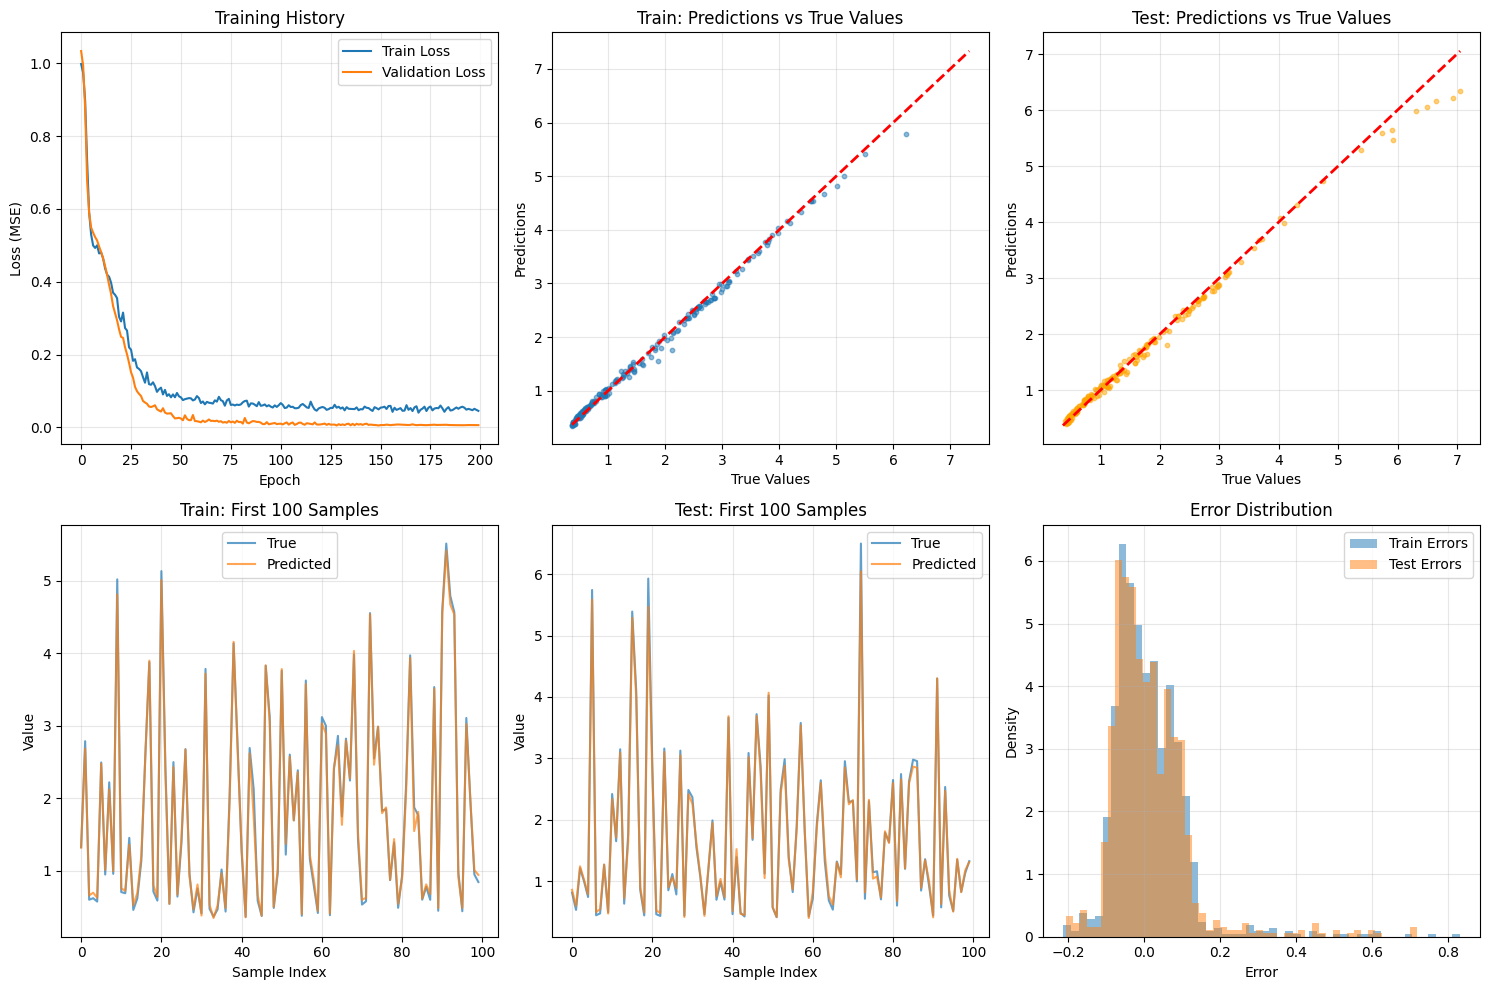

In [11]:
# 8. 可视化结果
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 训练过程
axes[0, 0].plot(train_losses, label='Train Loss')
axes[0, 0].plot(val_losses, label='Validation Loss')
axes[0, 0].set_title('Training History')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss (MSE)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 训练集预测 vs 真实值
axes[0, 1].scatter(train_true[:200], train_pred[:200], alpha=0.5, s=10)
axes[0, 1].plot([train_true.min(), train_true.max()], 
                [train_true.min(), train_true.max()], 
                'r--', lw=2)
axes[0, 1].set_title('Train: Predictions vs True Values')
axes[0, 1].set_xlabel('True Values')
axes[0, 1].set_ylabel('Predictions')
axes[0, 1].grid(True, alpha=0.3)

# 测试集预测 vs 真实值
axes[0, 2].scatter(test_true[:200], test_pred[:200], alpha=0.5, s=10, color='orange')
axes[0, 2].plot([test_true.min(), test_true.max()], 
                [test_true.min(), test_true.max()], 
                'r--', lw=2)
axes[0, 2].set_title('Test: Predictions vs True Values')
axes[0, 2].set_xlabel('True Values')
axes[0, 2].set_ylabel('Predictions')
axes[0, 2].grid(True, alpha=0.3)

# 训练集样本对比
axes[1, 0].plot(train_true[:100], label='True', alpha=0.7)
axes[1, 0].plot(train_pred[:100], label='Predicted', alpha=0.7)
axes[1, 0].set_title('Train: First 100 Samples')
axes[1, 0].set_xlabel('Sample Index')
axes[1, 0].set_ylabel('Value')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 测试集样本对比
axes[1, 1].plot(test_true[:100], label='True', alpha=0.7)
axes[1, 1].plot(test_pred[:100], label='Predicted', alpha=0.7)
axes[1, 1].set_title('Test: First 100 Samples')
axes[1, 1].set_xlabel('Sample Index')
axes[1, 1].set_ylabel('Value')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# 误差分布
train_errors = train_true.flatten() - train_pred.flatten()
test_errors = test_true.flatten() - test_pred.flatten()

axes[1, 2].hist(train_errors, bins=50, alpha=0.5, label='Train Errors', density=True)
axes[1, 2].hist(test_errors, bins=50, alpha=0.5, label='Test Errors', density=True)
axes[1, 2].set_title('Error Distribution')
axes[1, 2].set_xlabel('Error')
axes[1, 2].set_ylabel('Density')
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [12]:
# 9. 计算评估指标
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

train_mse = mean_squared_error(train_true, train_pred)
train_mae = mean_absolute_error(train_true, train_pred)
train_r2 = r2_score(train_true, train_pred)

test_mse = mean_squared_error(test_true, test_pred)
test_mae = mean_absolute_error(test_true, test_pred)
test_r2 = r2_score(test_true, test_pred)

print("\n" + "="*50)
print("评估指标:")
print("="*50)
print(f"训练集:")
print(f"  MSE:  {train_mse:.6f}")
print(f"  MAE:  {train_mae:.6f}")
print(f"  R²:   {train_r2:.6f}")
print(f"\n测试集:")
print(f"  MSE:  {test_mse:.6f}")
print(f"  MAE:  {test_mae:.6f}")
print(f"  R²:   {test_r2:.6f}")
print("="*50)


评估指标:
训练集:
  MSE:  0.010458
  MAE:  0.067160
  R²:   0.994380

测试集:
  MSE:  0.011576
  MAE:  0.070445
  R²:   0.994034


In [ ]:
# 10. 模型复杂度分析
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\n模型参数量: {count_parameters(model):,}")


模型参数量: 52,801


3、使用Darts进行LSTM股价预测

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from darts import TimeSeries
from darts.models import RNNModel
from darts.dataprocessing.transformers import Scaler
from darts.metrics import mape, rmse, mae
from darts.utils.timeseries_generation import datetime_attribute_timeseries
import warnings
warnings.filterwarnings('ignore')

e:\本科毕业论文\神经网络方法\pykan\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [33]:
# ==================== 1. 数据加载和预处理 ====================
def load_and_prepare_data(file_path):
    """
    加载CSV文件并转换为Darts TimeSeries列表
    假设CSV包含列: trade_date, ts_code, open, high, low, close, volume, ...
    """
    print("正在加载数据...")
    df = pd.read_csv(file_path, parse_dates=['trade_date'])
    
    # 按股票代码分组
    stock_groups = df.groupby('ts_code')
    series_list = []
    
    for stock_code, group in stock_groups:
        # 按日期排序
        group = group.sort_values('trade_date')
        
        # 选择特征列（根据你的实际列名调整）
        # 基础价格和成交量是必须的，其他技术指标可选
        value_cols = ['close', 'open', 'high', 'low', 'pre_close', 'change', 'pct_chg', 'vol', 'amount', 'open_qfq', 'high_qfq', 'low_qfq', 'close_qfq', 'pre_close_qfq', 'open_hfq', 'high_hfq', 'low_hfq', 'close_hfq', 'pre_close_hfq', 'turnover_rate', 'turnover_rate_f', 'volume_ratio', 'pe', 'pe_ttm', 'pb', 'ps', 'ps_ttm', 'dv_ratio', 'dv_ttm', 'total_share', 'float_share', 'free_share', 'total_mv', 'circ_mv', 'adj_factor',  'ema_bfq_250', 'ema_qfq_250', 'ema_hfq_250']  # 目标变量
        # 如果你想用多变量预测，可以加入更多列
        # value_cols = ['close', 'volume', 'open', 'high', 'low']
        
        # 转换为Darts TimeSeries
        series = TimeSeries.from_dataframe(
            group,
            time_col='trade_date',
            value_cols=value_cols,
            fill_missing_dates=True,  # 自动填充缺失日期
            freq='D'  # 日线数据
        )
        
        # 只保留有足够数据的股票（比如至少500个交易日）
        if len(series) >= 500:
            series_list.append(series)
            if len(series_list) <= 5:  # 只打印前5只的信息
                print(f"股票 {stock_code}: {len(series)} 个交易日")
    
    print(f"成功加载 {len(series_list)} 只股票的数据")
    return series_list

In [34]:
series_list = load_and_prepare_data('all_factors_20150101_20251231.csv')

正在加载数据...
股票 000001.SZ: 4014 个交易日
股票 000011.SZ: 4014 个交易日
股票 000014.SZ: 4014 个交易日
股票 000027.SZ: 4014 个交易日
股票 000096.SZ: 4014 个交易日
成功加载 210 只股票的数据


In [35]:
# ==================== 2. 划分函数 ====================
def split_by_time(series_list, train_end='2019-12-31', val_end='2023-12-31'):
    """
    严格按时间划分训练/验证/测试集
    使用Darts内置的切片方法
    """
    train_series = []
    val_series = []
    test_series = []
    
    # 转换日期
    train_end_ts = pd.Timestamp(train_end)
    val_end_ts = pd.Timestamp(val_end)
    
    # 记录每只股票的划分情况
    stock_stats = []
    
    for i, series in enumerate(series_list):
        try:
            # 方法1: 使用split_before和split_after（推荐）
            # 先切出训练集
            train_part, rest = series.split_before(train_end_ts)
            
            # 从剩余部分切出验证集和测试集
            val_part, test_part = rest.split_before(val_end_ts)
            
            # 添加到对应的列表
            if len(train_part) > 0:
                train_series.append(train_part)
            if len(val_part) > 0:
                val_series.append(val_part)
            if len(test_part) > 0:
                test_series.append(test_part)
            
            # 记录前3只股票的详细信息
            if i < 3:
                stock_stats.append({
                    'index': i,
                    '总天数': len(series),
                    '训练集天数': len(train_part) if len(train_part) > 0 else 0,
                    '验证集天数': len(val_part) if len(val_part) > 0 else 0,
                    '测试集天数': len(test_part) if len(test_part) > 0 else 0,
                    '训练集范围': f"{train_part.start_time()} 到 {train_part.end_time()}" if len(train_part) > 0 else "无",
                    '验证集范围': f"{val_part.start_time()} 到 {val_part.end_time()}" if len(val_part) > 0 else "无",
                    '测试集范围': f"{test_part.start_time()} 到 {test_part.end_time()}" if len(test_part) > 0 else "无"
                })
                
        except Exception as e:
            print(f"处理股票 {i} 时出错: {e}")
            continue
    
    print(f"\n训练集: {len(train_series)} 只股票")
    print(f"验证集: {len(val_series)} 只股票")
    print(f"测试集: {len(test_series)} 只股票")
    
    # 打印前3只股票的详细划分信息
    if stock_stats:
        print("\n前3只股票划分详情:")
        for stat in stock_stats:
            print(f"\n股票 {stat['index']+1}:")
            print(f"  总天数: {stat['总天数']}")
            print(f"  训练集: {stat['训练集天数']}天 ({stat['训练集范围']})")
            print(f"  验证集: {stat['验证集天数']}天 ({stat['验证集范围']})")
            print(f"  测试集: {stat['测试集天数']}天 ({stat['测试集范围']})")
    
    return train_series, val_series, test_series

In [36]:
train_series, val_series, test_series = split_by_time(series_list, train_end='2019-12-31', val_end='2023-12-31')


训练集: 210 只股票
验证集: 210 只股票
测试集: 210 只股票

前3只股票划分详情:

股票 1:
  总天数: 4014
  训练集: 1821天 (2015-01-05 00:00:00 到 2019-12-30 00:00:00)
  验证集: 1461天 (2019-12-31 00:00:00 到 2023-12-30 00:00:00)
  测试集: 732天 (2023-12-31 00:00:00 到 2025-12-31 00:00:00)

股票 2:
  总天数: 4014
  训练集: 1821天 (2015-01-05 00:00:00 到 2019-12-30 00:00:00)
  验证集: 1461天 (2019-12-31 00:00:00 到 2023-12-30 00:00:00)
  测试集: 732天 (2023-12-31 00:00:00 到 2025-12-31 00:00:00)

股票 3:
  总天数: 4014
  训练集: 1821天 (2015-01-05 00:00:00 到 2019-12-30 00:00:00)
  验证集: 1461天 (2019-12-31 00:00:00 到 2023-12-30 00:00:00)
  测试集: 732天 (2023-12-31 00:00:00 到 2025-12-31 00:00:00)


In [37]:
# ==================== 3. 数据标准化 ====================
def normalize_series(train_series, val_series, test_series):
    """
    在训练集上拟合scaler，然后转换验证集和测试集
    避免数据泄露
    """
    # 对所有股票使用同一个scaler（保持尺度一致）
    scaler = Scaler()
    
    # 在训练集上拟合
    train_scaled = [scaler.fit_transform(series) for series in train_series]
    
    # 转换验证集和测试集
    val_scaled = [scaler.transform(series) for series in val_series] if val_series else []
    test_scaled = [scaler.transform(series) for series in test_series] if test_series else []
    
    print("数据标准化完成")
    return train_scaled, val_scaled, test_scaled, scaler

In [38]:
train_scaled, val_scaled, test_scaled, scaler = normalize_series(train_series, val_series, test_series)

数据标准化完成


In [39]:
# ==================== 4. 创建协变量（可选） ====================
def create_covariates(series_list):
    """
    创建时间特征作为未来协变量
    例如：月份、星期几、节假日等
    """
    covariate_list = []
    
    for series in series_list:
        # 获取时间索引
        time_idx = series.time_index
        
        # 创建月份特征（周期性编码）
        month_series = datetime_attribute_timeseries(
            time_idx, 
            attribute='month',
            cyclic=True  # 循环编码，让12月和1月接近
        )
        
        # 创建星期特征
        day_series = datetime_attribute_timeseries(
            time_idx,
            attribute='dayofweek',
            cyclic=True
        )
        
        # 合并协变量
        covariates = month_series.stack(day_series)
        covariate_list.append(covariates)
    
    return covariate_list

In [40]:
# ==================== 5. 模型训练 ====================
def train_lstm_model(train_scaled, val_scaled, input_chunk_length=60):

    print("\n开始训练LSTM模型...")
    print(f"参数设置: input_chunk_length={input_chunk_length}, output_chunk_length=1")
    
    # 计算training_length
    training_length = input_chunk_length + 24
    
    # 创建LSTM模型 - 完全禁用日志
    model = RNNModel(
        model='LSTM',
        input_chunk_length=input_chunk_length,
        output_chunk_length=1,
        training_length=training_length,
        hidden_dim=128,
        n_rnn_layers=2,
        dropout=0.2,
        batch_size=64,
        n_epochs=10,
        optimizer_kwargs={'lr': 1e-3},
        random_state=42,
        force_reset=True,
        pl_trainer_kwargs={
            'accelerator': 'auto',
            'devices': 'auto',
            'enable_progress_bar': True,
            'enable_model_summary': True,
            'logger': False,  # 禁用日志！
            'log_every_n_steps': 0,  # 不记录日志
        }
    )
    
    # 训练模型
    model.fit(
        series=train_scaled,
        val_series=val_scaled if val_scaled else None,
        verbose=True
    )
    
    print("模型训练完成")
    return model

In [41]:
train_scaled = train_scaled[:1]
model=train_lstm_model(train_scaled, val_scaled, input_chunk_length=60)

ignoring user defined `output_chunk_length`. RNNModel uses a fixed `output_chunk_length=1`.


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.



开始训练LSTM模型...
参数设置: input_chunk_length=60, output_chunk_length=1


┏━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name            ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ criterion       │ MSELoss          │      0 │ eval  │     0 │
│ 1 │ train_criterion │ MSELoss          │      0 │ eval  │     0 │
│ 2 │ val_criterion   │ MSELoss          │      0 │ eval  │     0 │
│ 3 │ train_metrics   │ MetricCollection │      0 │ train │     0 │
│ 4 │ val_metrics     │ MetricCollection │      0 │ train │     0 │
│ 5 │ rnn             │ LSTM             │  218 K │ train │     0 │
│ 6 │ V               │ Linear           │  4.9 K │ train │     0 │
└───┴─────────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 223 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 223 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 4                                                                                           
Modules in eval mode: 3                                                                                            
Total FLOPs: 0


Detected KeyboardInterrupt, attempting graceful shutdown ...


SystemExit: 1

In [29]:
# ==================== 6. 模型评估 ====================
def evaluate_model(model, test_scaled, scaler, n_predict=30):
    """
    在测试集上评估模型
    """
    print("\n开始评估模型...")
    
    all_mape = []
    all_rmse = []
    
    # 对每只测试股票进行预测
    for i, test_series in enumerate(test_scaled[:10]):  # 只测试前10只，避免太慢
        # 划分历史数据和待预测数据
        history = test_series[:-n_predict] if len(test_series) > n_predict else test_series[:-1]
        true_future = test_series[-n_predict:] if len(test_series) > n_predict else test_series[-1:]
        
        if len(history) < model.input_chunk_length:
            continue
        
        # 预测
        forecast = model.predict(
            n=len(true_future),
            series=history
        )
        
        # 反标准化回原始尺度
        forecast_original = scaler.inverse_transform(forecast)
        true_original = scaler.inverse_transform(true_future)
        
        # 计算指标
        mape_val = mape(true_original, forecast_original)
        rmse_val = rmse(true_original, forecast_original)
        
        all_mape.append(mape_val)
        all_rmse.append(rmse_val)
        
        if i < 3:  # 打印前3只的结果
            print(f"股票 {i+1}: MAPE={mape_val:.2f}%, RMSE={rmse_val:.2f}")
        
        # 绘制预测结果（可选）
        if i == 0:
            plt.figure(figsize=(12, 6))
            true_original.plot(label='Actual', lw=2)
            forecast_original.plot(label='Forecast', lw=2)
            plt.title(f'Stock {i+1} Price Prediction')
            plt.legend()
            plt.grid(True)
            plt.savefig('prediction_example.png')
            plt.show()
    
    # 总体结果
    print(f"\n总体结果（基于{len(all_mape)}只股票）:")
    print(f"平均MAPE: {np.mean(all_mape):.2f}%")
    print(f"平均RMSE: {np.mean(all_rmse):.2f}")
    
    return all_mape, all_rmse


# ==================== 7. 回测（可选） ====================
def backtest_model(model, train_scaled, test_scaled, scaler, horizon=30):
    """
    对模型进行回测，模拟真实交易场景
    """
    print("\n开始回测...")
    
    # 合并训练集和测试集（但按时间顺序）
    full_series = train_scaled + test_scaled
    
    backtest_results = []
    
    for series in full_series[:5]:  # 只测试5只
        if len(series) < model.input_chunk_length + horizon:
            continue
            
        # 历史回测
        backtest = model.historical_forecasts(
            series,
            start=0.8,  # 从80%的时间点开始回测
            forecast_horizon=horizon,
            stride=5,   # 每5天滑动一次
            retrain=False,  # 不重新训练（节省时间）
            verbose=False
        )
        
        # 计算误差
        error = mape(series, backtest)
        backtest_results.append(error)
        
        # 绘制回测结果（选第一只）
        if len(backtest_results) == 1:
            plt.figure(figsize=(12, 6))
            series[-200:].plot(label='Actual')
            backtest[-200:].plot(label='Backtest')
            plt.title('Backtest Example')
            plt.legend()
            plt.grid(True)
            plt.savefig('backtest_example.png')
            plt.show()
    
    print(f"回测平均MAPE: {np.mean(backtest_results):.2f}%")
    return backtest_results

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.



开始评估模型...


股票 1: MAPE=nan%, RMSE=nan


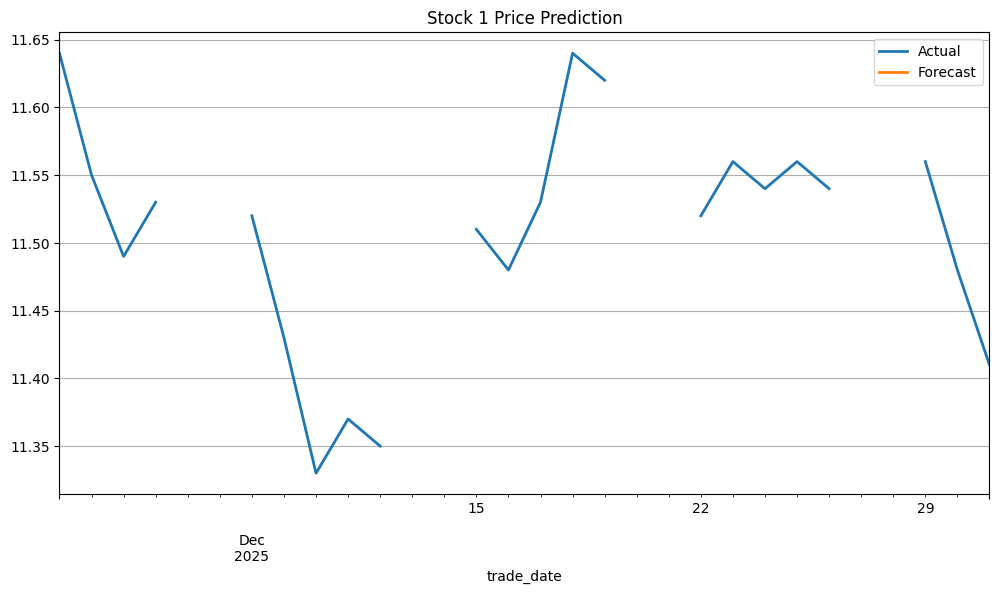

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


股票 2: MAPE=nan%, RMSE=nan


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


股票 3: MAPE=nan%, RMSE=nan


...

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.



总体结果（基于10只股票）:
平均MAPE: nan%
平均RMSE: nan


In [30]:
all_mape, all_rmse=evaluate_model(model, test_scaled, scaler, n_predict=30)

In [61]:
# ==================== 8. 主程序 ====================
def main():
    # 配置参数
    CSV_PATH = 'all_factors_20150101_20251231.csv'  # 请修改为你的文件路径
    TRAIN_END = '2019-12-31'
    VAL_END = '2023-12-31'
    INPUT_LENGTH = 60  # 用60天预测下一天
    OUTPUT_LENGTH = 1  # 预测1天
    
    # 1. 加载数据
    series_list = load_and_prepare_data(CSV_PATH)
    
    # 2. 划分数据集
    train_raw, val_raw, test_raw = split_by_time(
        series_list, 
        train_end=TRAIN_END, 
        val_end=VAL_END
    )
    
    # 3. 标准化
    train_scaled, val_scaled, test_scaled, scaler = normalize_series(
        train_raw, val_raw, test_raw
    )
    
    # 4. 训练模型（使用修复后的函数）
    model = train_lstm_model(
        train_scaled, 
        val_scaled,
        input_chunk_length=INPUT_LENGTH
    )
    
    # 5. 保存模型
    model.save('lstm_stock_model.pth')
    print("模型已保存为 lstm_stock_model.pth")
    
    # 6. 评估模型
    if test_scaled:
        evaluate_model(model, test_scaled, scaler, n_predict=30)
    
    print("\n全部完成！")

In [62]:
if __name__ == "__main__":
    main()

正在加载数据...
股票 000001.SZ: 4014 个交易日
股票 000011.SZ: 4014 个交易日
股票 000014.SZ: 4014 个交易日
股票 000027.SZ: 4014 个交易日
股票 000096.SZ: 4014 个交易日
成功加载 210 只股票的数据

训练集: 210 只股票
验证集: 210 只股票
测试集: 210 只股票

前3只股票划分详情:

股票 1:
  总天数: 4014
  训练集: 1821天 (2015-01-05 00:00:00 到 2019-12-30 00:00:00)
  验证集: 1461天 (2019-12-31 00:00:00 到 2023-12-30 00:00:00)
  测试集: 732天 (2023-12-31 00:00:00 到 2025-12-31 00:00:00)

股票 2:
  总天数: 4014
  训练集: 1821天 (2015-01-05 00:00:00 到 2019-12-30 00:00:00)
  验证集: 1461天 (2019-12-31 00:00:00 到 2023-12-30 00:00:00)
  测试集: 732天 (2023-12-31 00:00:00 到 2025-12-31 00:00:00)

股票 3:
  总天数: 4014
  训练集: 1821天 (2015-01-05 00:00:00 到 2019-12-30 00:00:00)
  验证集: 1461天 (2019-12-31 00:00:00 到 2023-12-30 00:00:00)
  测试集: 732天 (2023-12-31 00:00:00 到 2025-12-31 00:00:00)


ignoring user defined `output_chunk_length`. RNNModel uses a fixed `output_chunk_length=1`.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


数据标准化完成

开始训练LSTM模型...
参数设置: input_chunk_length=60, output_chunk_length=1


┏━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name            ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ criterion       │ MSELoss          │      0 │ train │     0 │
│ 1 │ train_criterion │ MSELoss          │      0 │ train │     0 │
│ 2 │ val_criterion   │ MSELoss          │      0 │ train │     0 │
│ 3 │ train_metrics   │ MetricCollection │      0 │ train │     0 │
│ 4 │ val_metrics     │ MetricCollection │      0 │ train │     0 │
│ 5 │ rnn             │ LSTM             │  203 K │ train │     0 │
│ 6 │ V               │ Linear           │  1.2 K │ train │     0 │
└───┴─────────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 204 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 204 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 7                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0


Detected KeyboardInterrupt, attempting graceful shutdown ...


SystemExit: 1